Boissier, S., & Prantzos, N. 1999, MNRAS, 307, 857

Boissier, S., & Prantzos, N. 2000, MNRAS, 312, 398

mc-spf DATA/Coma/NGC4848/region_photometry.fits filters.txt --sfh 'SFHs_Boissier/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' FITPHOT

mc-spf DATA/GMP3779/region_photometry.fits filters.txt --sfh 'SFHs_Boisser/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' --timerange '12500,13500' PLOT

mc-spf DATA/GMP3779/region_photometry.fits filters.txt --sfh 'SFHs_Boisser/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' FIT



# Scaling relation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Scaling relations

Rd_MW = 2.6                # kpc
Sigma_0_MW = 1150          # solar masses / pc2
Vc_MW = 220                # km/s
spin_MW = 0.03 
md_MW = 0.05
M_MW = 1e12                 # Msun
Md_MW = 0.05 * 1e12         # Msun

md = 0.05
jd = 0.05

def M(Vc):
    return  M_MW * (Vc / Vc_MW)**3

def Md(Vc,md):
    return  md * M(Vc)

def Rd(Vc,spin):
    return  Rd_MW * (spin / spin_MW) * (Vc / Vc_MW)

def Sigma_0(Vc,spin): 
    return Sigma_0_MW * (md / md_MW) * (spin / spin_MW)**-2 * (Vc / Vc_MW)

def surface_density(R,Vc,spin):
    return Sigma_0(Vc,spin) * np.exp(-R/Rd(Vc,spin))


def Vc_to_Md(Vc): return Md(Vc,md = 0.05)
def Md_to_Vc(Md): return Vc_MW * (Md / Md_MW)**(1/3)
    

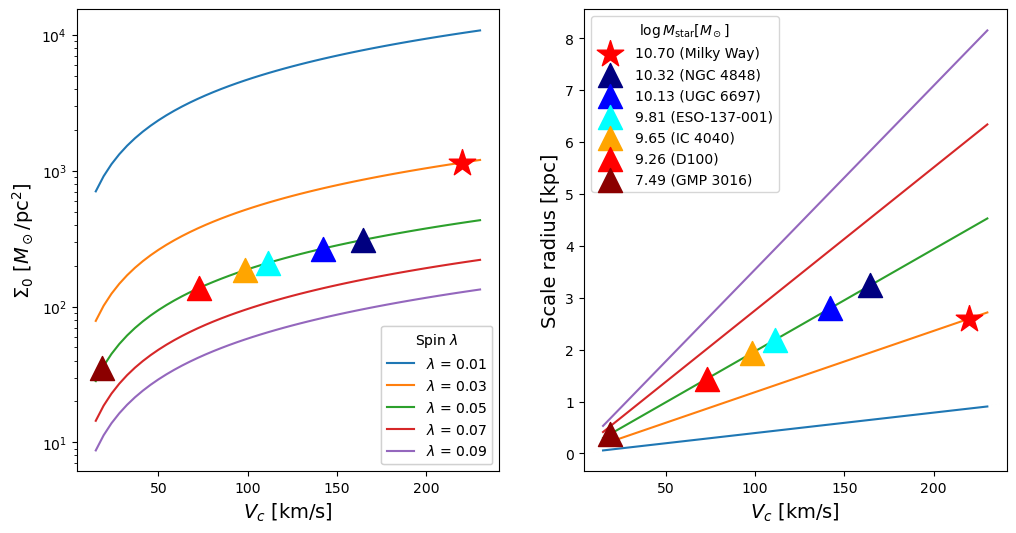

In [3]:
# --- Galaxy Sample ---
sample_galaxies = {
    'NGC 4848': 10.32,
    'UGC 6697': 10.13,
    'ESO-137-001': 9.81,
    'IC 4040': 9.65,
    'D100': 9.26,
    'GMP 3016': 7.49
}

colors = ['navy','blue', 'cyan', 'orange', 'red', 'darkred']

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
v = np.linspace(15, 230)

# Plot model curves for different spin parameters
spin_values = [0.01, 0.03, 0.05, 0.07, 0.09]
spin_handles = []

for l in spin_values:
    h0, = ax[0].plot(v, Sigma_0(v, l), label=f'$\lambda$ = {l:.2f}')
    h1, = ax[1].plot(v, Rd(v, l), label=f'$\lambda$ = {l:.2f}')
    spin_handles.append(h0)  # store only one handle per spin


galaxy_handles = []
h = ax[0].scatter(Vc_MW, Sigma_0_MW, marker='*', c='red', edgecolor='red', s=400, label=f"{np.log10(Vc_to_Md(220)):.2f} (Milky Way)",zorder=5)
ax[1].scatter(Vc_MW, Rd_MW, marker='*', c='red', edgecolor='red', s=400,zorder=5)
galaxy_handles.append(h)

for i, gal in enumerate(sample_galaxies.keys()):
    logMd = sample_galaxies[gal]
    Md_val = 10**logMd
    Vc_gal = Md_to_Vc(Md_val)
    Sigma_0_gal = Sigma_0(Vc_gal, 0.05)
    Rd_gal = Rd(Vc_gal, 0.05)

    h = ax[0].scatter(Vc_gal, Sigma_0_gal, color = colors[i], marker='^', s=300, label=f"{sample_galaxies[gal]} ({gal})",zorder=5)
    ax[1].scatter(Vc_gal, Rd_gal, color = colors[i], marker='^', s=300,zorder=5)
    galaxy_handles.append(h)

# Axis labels
for i in range(2):
    ax[i].set_xlabel('$V_c$ [km/s]',fontsize=14)
ax[0].set_ylabel(r'$\Sigma_0$ [$M_\odot$/pc$^2$]',fontsize=14)
ax[1].set_ylabel('Scale radius [kpc]',fontsize=14)
ax[0].set_yscale('log')

# Two legends on left panel
spin_legend = ax[0].legend(handles=spin_handles, loc='lower right', title='Spin $\lambda$')
ax[0].add_artist(spin_legend)
ax[1].legend(handles=galaxy_handles, loc='upper left', title='$\log M_\\text{star} [M_\odot]$')

# Secondary axes created ONCE and BEFORE plt.show()
#secax0 = ax[0].secondary_xaxis('top', functions=(Vc_to_Md, Md_to_Vc))
#secax1 = ax[1].secondary_xaxis('top', functions=(Vc_to_Md, Md_to_Vc))
#secax0.set_xlabel('$M_d$ [$M_\\odot$]')
#secax1.set_xlabel('$M_d$ [$M_\\odot$]')

#plt.tight_layout()
plt.show()



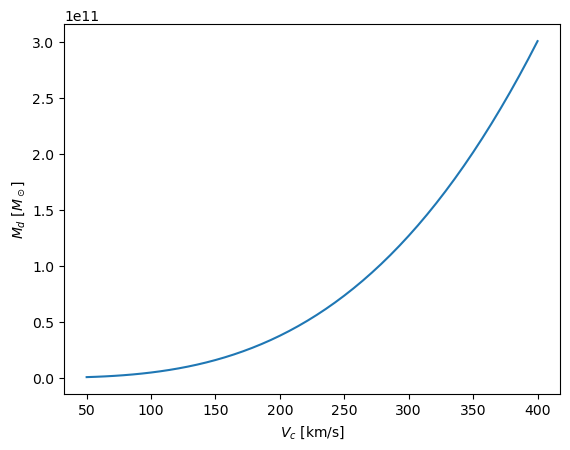

In [4]:
V_array = np.linspace(50,400)

fig,ax=plt.subplots()
ax.plot(V_array, Vc_to_Md(V_array))
#ax.set_aspect('equal')

ax.set_xlabel('$V_c$ [km/s]')
ax.set_ylabel('$M_d$ [$M_\odot$]')

plt.show()


In [5]:
# Velocity curves
from scipy.interpolate import interp1d
from scipy.special import iv as I, kv as K

G = 4.301e-6         # (kpc * (km/s)^2) / M_sun
rho0 = 0.015 * 1e9   # M_sun/kpc^3   0.008 - 0.015
Rc_MW = 5            # kpc -5 to 10

def Rc(Vc,spin):
    return Rc_MW * (spin/spin_MW) * (Vc/Vc_MW)

def rho_0(Vc,spin):
    return Vc**2 / (4*np.pi*G*Rc(Vc,spin)**2)


def velocity_profile(Vc, spin, disk=True):

    R = np.linspace(0.03, 50, 500)

    # Disk component
    sigma_0 = Sigma_0(Vc, spin)
    rd = Rd(Vc, spin)
    y = R / (2*rd)
    Vd_squared = 4 * np.pi * G * (sigma_0 * 1e6) * rd * y**2 * (I(0, y) * K(0, y) - I(1, y) * K(1, y))
    
    # Halo component
    rho0_val = rho_0(Vc, spin)
    rc = Rc(Vc, spin)
    Vh_squared = 4 * np.pi * G * rho0_val * rc**2 * (1 - (rc / R) * np.arctan(R / rc))

    # Total rotation curve
    V_total = np.sqrt(Vd_squared + Vh_squared)

    V_interp = interp1d(R, V_total, kind='linear', bounds_error=False, fill_value='extrapolate')

    return V_interp


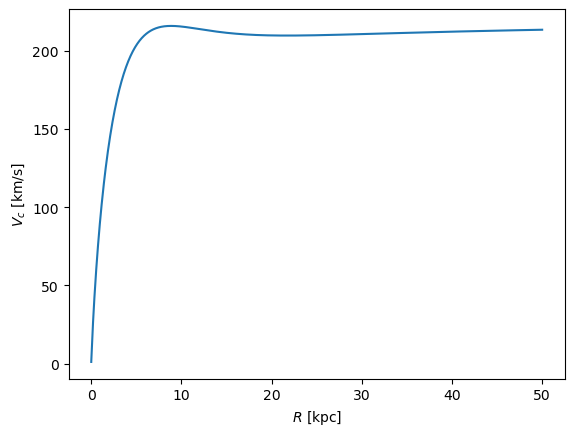

In [6]:
fig,ax = plt.subplots()

r = np.linspace(0,50,1000)
plt.plot(r,velocity_profile(220,0.03)(r))

ax.set_xlabel('$R$ [kpc]')
ax.set_ylabel('$V_c$ [km/s]')

plt.show()

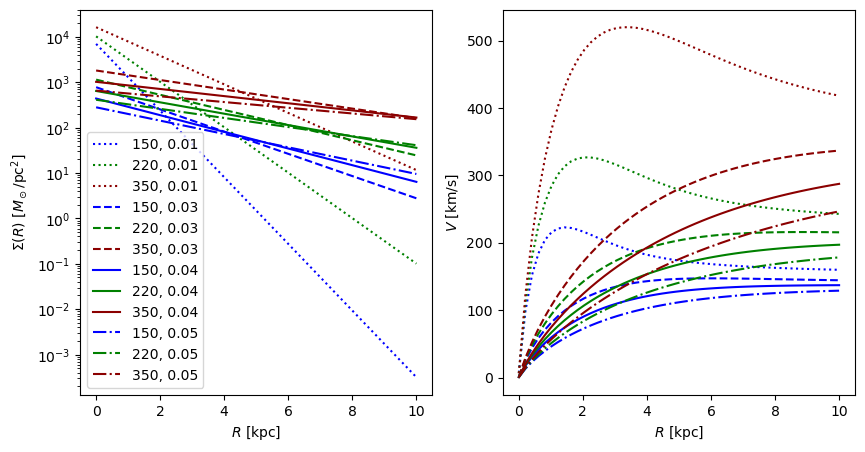

In [7]:
fig,ax = plt.subplots(1,2,figsize=(10,5))


r = np.linspace(0,10)

for l,ls in zip([0.01,0.03,0.04,0.05], [':','--','-','-.']):
    for Vc,c in zip([150,220,350], ['blue','green','darkred']):

        ax[0].plot(r,surface_density(r,Vc,l),linestyle=ls,color=c,label=f'{Vc}, {l}')
        ax[0].set_yscale('log')
        ax[0].set_xlabel('$R$ [kpc]')
        ax[0].set_ylabel('$\Sigma(R)$ [$M_\odot$/pc$^2$]')

        ax[0].legend()
        
        ax[1].plot(r, velocity_profile(Vc,l)(r),linestyle=ls,color=c)
        ax[1].set_xlabel('$R$ [kpc]')
        ax[1].set_ylabel('$V$ [km/s]')


# Boissier models

In [8]:
import os, glob, re
import numpy as np
from astropy.io import fits
import tempfile

# Base directory containing the “DISKEVOL.RES_L0.05_V*” files
data_dir = "SFHs_Boissier/boissier_models_big_grid"

# Pattern to match files without “lignes” in their name
file_pattern = os.path.join(data_dir, "DISKEVOL.RES_L0.05_V*")

# Regex to extract the integer velocity after “_V”
vel_pattern = re.compile(r"_V(\d+)")
# First, collect (velocity, full_path) pairs
velocity_files = []
for full_path in glob.glob(file_pattern):
    fname = os.path.basename(full_path)
    if "lignes" in fname:
        continue
    m = vel_pattern.search(fname)
    if not m:
        continue
    velocity = int(m.group(1))
    velocity_files.append((velocity, full_path))

# Sort by velocity (ascending)
velocity_files.sort(key=lambda vf: vf[0])

# Now build the dictionary in sorted order
boissier_models = {}
for velocity, full_path in velocity_files:
    boissier_models[velocity] = {}   # Initialize nested dict for this velocity

    current_radius = None
    boissier_models_by_radius = {}   # Temporary storage: radius → list of rows

    with open(full_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("99999"):
                # Skip empty lines or separator lines
                continue

            if line.startswith("R ="):
                parts = line.split()
                try:
                    # Parse “R = 1.24 kpc” → radius = 1.24
                    current_radius = float(parts[2])
                    boissier_models_by_radius[current_radius] = []
                except (IndexError, ValueError):
                    current_radius = None
                continue

            if current_radius is None:
                continue

            parts = line.split()
            if len(parts) < 6:
                continue

            try:
                # Convert columns 1–5 to float
                row = [float(x) for x in parts[1:6]]
                boissier_models_by_radius[current_radius].append(row)
            except ValueError:
                continue

    # Convert each list of rows into a NumPy array, then store under data[velocity]
    for radius, rows in boissier_models_by_radius.items():
        boissier_models[velocity][radius] = np.array(rows)

# Example: print out velocity → radius → array shape (velocities will be in ascending order)
#for v in data:
#    for r in sorted(data[v]):
#        arr = data[v][r]
#        print(f"Velocity = {v} km/s, Radius = {r:.2f} kpc → Shape = {arr.shape}")



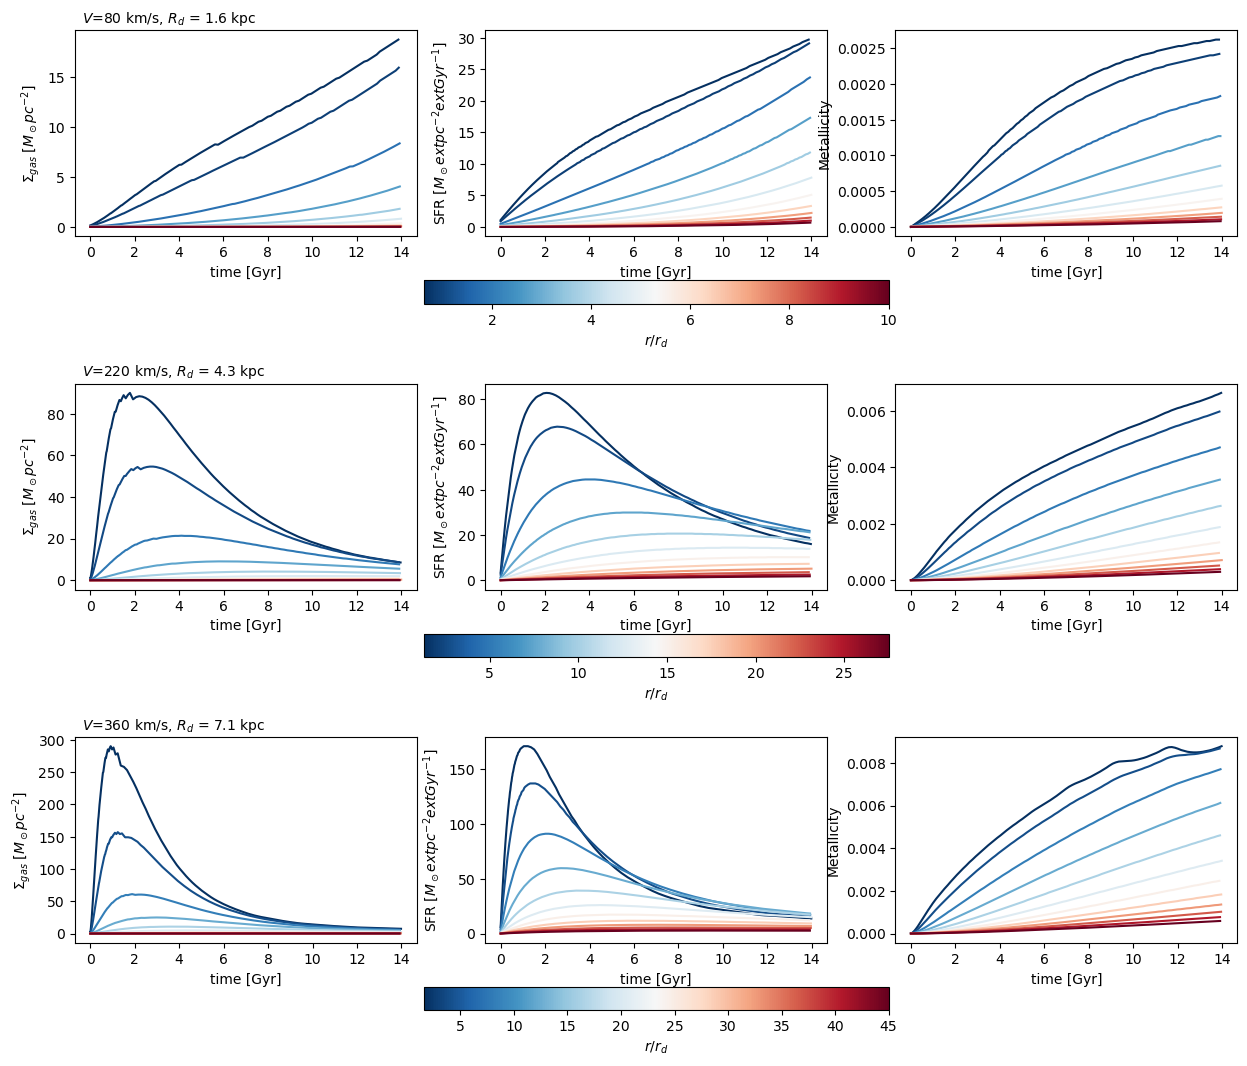

In [9]:
fig,ax = plt.subplots(3,3,figsize=(15,13))

for k,v in enumerate([80,220,360]):

    rd = Rd(v,0.05)                         # scale radius
    radii = sorted(boissier_models[v].keys())
    r_min, r_max = radii[0], radii[-1]
    norm = plt.Normalize(vmin=r_min, vmax=r_max)

    cmap = plt.cm.RdBu_r
    
    for r in radii:
        
        c = cmap(norm(r))
        
        t = boissier_models[v][r][:,0]
        sigma = boissier_models[v][r][:,1]
        sfr = boissier_models[v][r][:,2]
        Z = boissier_models[v][r][:,3]

        ax[k,0].plot(t,sigma,color=c,label=f"{r/rd:.2f}")
        ax[k,1].plot(t,sfr,color=c)
        ax[k,2].plot(t,Z,color=c)

    # Add a colorbar for this row, showing radii / rd
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(radii)
    cbar = fig.colorbar(sm, ax=ax[k, :], orientation='horizontal', pad=0.15,shrink=0.4)
    cbar.set_label(r"$r/r_d$")


    for i in range(3): ax[k,i].set_xlabel('time [Gyr]')
    ax[k, 0].set_ylabel('$\Sigma_{gas}$ [$M_\odot pc^{-2}$]')
    ax[k, 1].set_ylabel('SFR [$M_\odot \text{pc}^{-2} \text{Gyr}^{-1}$]')
    ax[k, 2].set_ylabel("Metallicity")
    ax[k,0].text(0.02, 1.1, f"$V$={v} km/s, $R_d$ = {rd:.1f} kpc", transform=ax[k,0].transAxes, va="top", ha="left")

#plt.tight_layout()
plt.show()


In [30]:
from build_boissier import truncated_boissier_sfh, truncated_boissier_sed, build_boissier_SEDs, load_spectrum_models_from_fits



In [11]:
t,sfr = truncated_boissier_sfh(V=160,R=1,Q_age=150,tau_Q=5,burst_factor=2,data=boissier_models)

(13000.0, 13500.0)

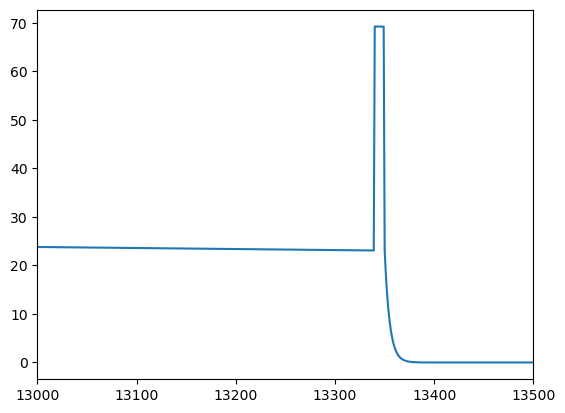

In [12]:
plt.plot(t,sfr)
plt.xlim(13000,13500)

In [32]:
# SFH quenching  #Lookback time for quenching Myr and attenuation factor for quenching
SFH_QUENCHING_TAU    = [2,8,12,16]#,20,28,30,35,40,45,50,75,100,125,150,175,200,250,300,400,500,1000]
SFH_QUENCHING_AGE    = [10,20,30,40]#,50,60,70,80,90,100,120,140,160,180,200,240,280,300,350,400,450,500,550,600,650,700,800,900,1000]
#SFH_QUENCHING_TAU    = [1,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,35,40,45,50,75,100,125,150,175,200,250,300,350,400,450,500,600,700,800,900,1000,2000]
#SFH_QUENCHING_AGE    = [2,4,6,8,10,20,30,40,50,60,70,80,90,100,120,140,160,180,200,220,240,260,280,300,325,350,375,400,425,450,475,500,550,600,650,700,750,800,850,900,950,1000,1500,2000,2500,3000]
BURST_FACTOR = [0,10,]#100]
# Bruzual and Charlot SSP
METALLICITIES = [0.008,0.014,]#0.017,0.03] 




In [33]:
specs = build_boissier_SEDs(V=160,R=7.5,
                                SFH_QUENCHING_AGE=SFH_QUENCHING_AGE,
                                SFH_QUENCHING_TAU=SFH_QUENCHING_TAU,
                                BURST_FACTORS=BURST_FACTOR,
                                METALLICITIES=METALLICITIES,
                                filename='V_160_R_7_Z_017.fit',
                                data=boissier_models)




Generating 64 models


Processing combinations: 100%|██████████████████| 64/64 [01:18<00:00,  1.22s/it]


In [17]:
specs = load_spectrum_models_from_fits(filename='V_160_R_7.fit')

In [21]:
specs[0].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   12 / length of dimension 1                          
NAXIS2  =                16688 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'FLUX    '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'FLUX_YOUNG'                                                          
TFORM2  = 'E       '                                                            
TTYPE3  = 'FLUX_OLD'        

In [24]:

legend = {'Q_AGE': "$Q_\\text{age}$", 'TAU_Q': "$\\tau_Q$", 'BURST': 'burst', 'METAL': 'metallicity'}
#legend = {'Q_AGE': 'AGE', 'TAU_Q': 'TAU', 'BURST': 'burst', 'METAL': 'metallicity'}


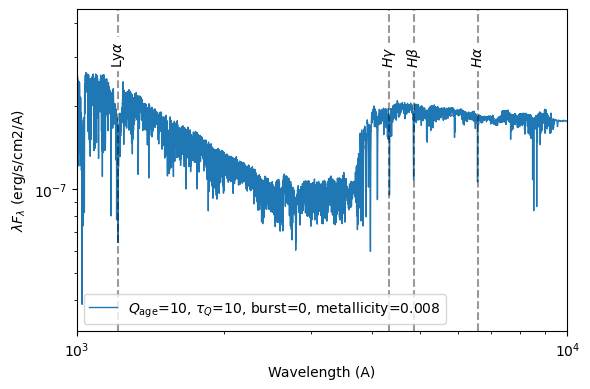

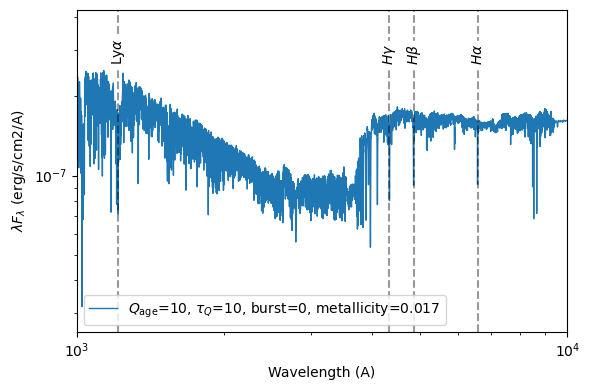

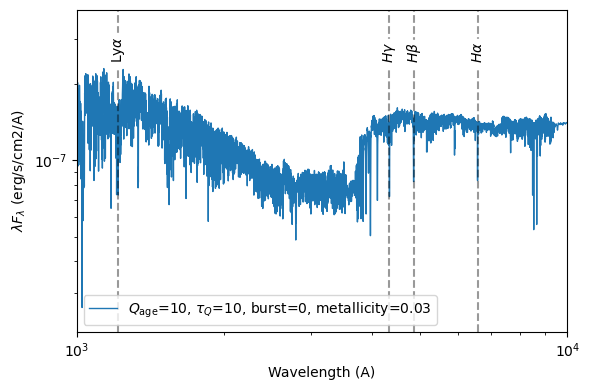

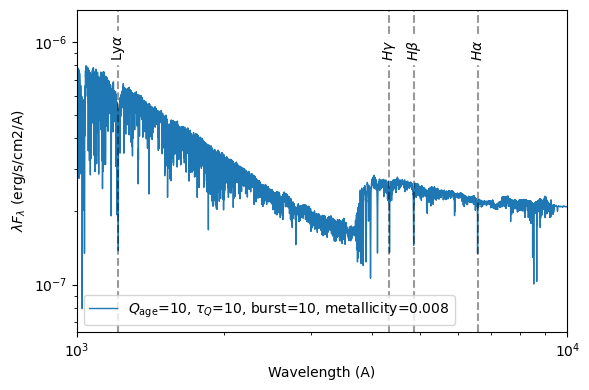

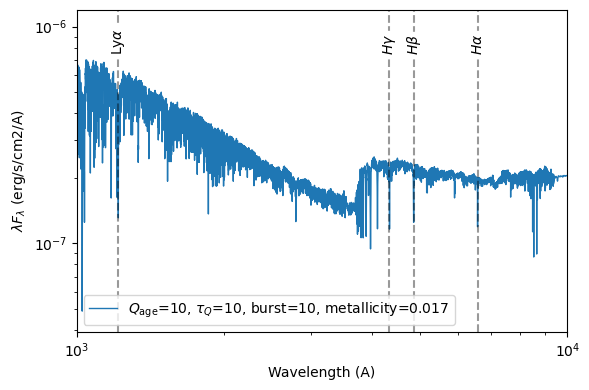

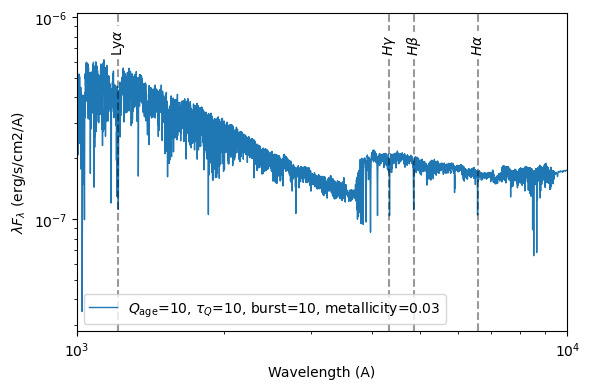

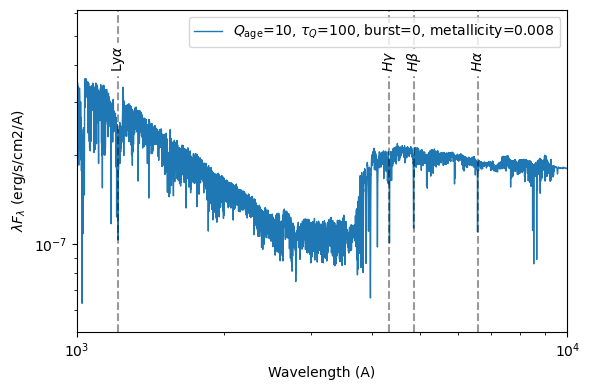

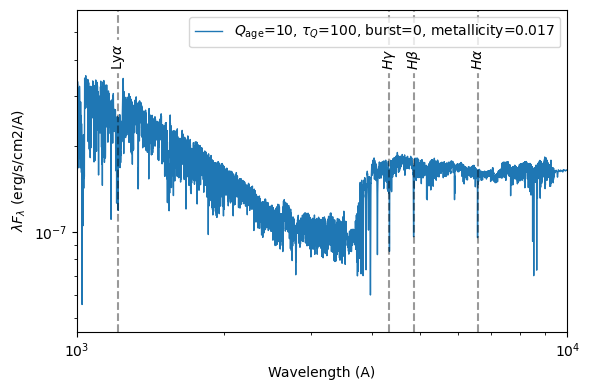

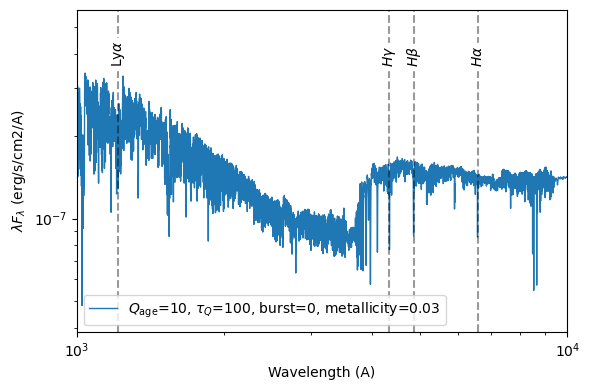

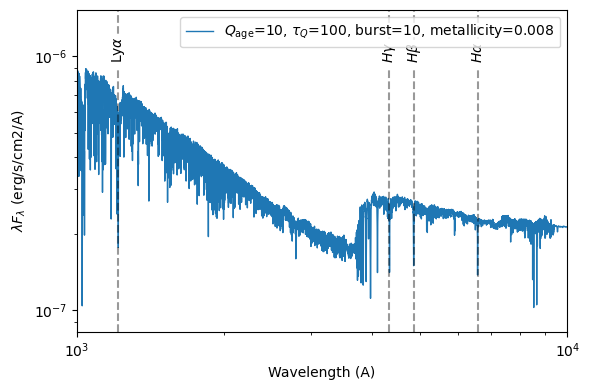

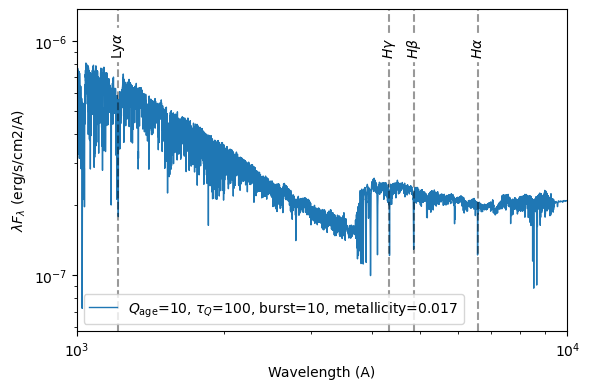

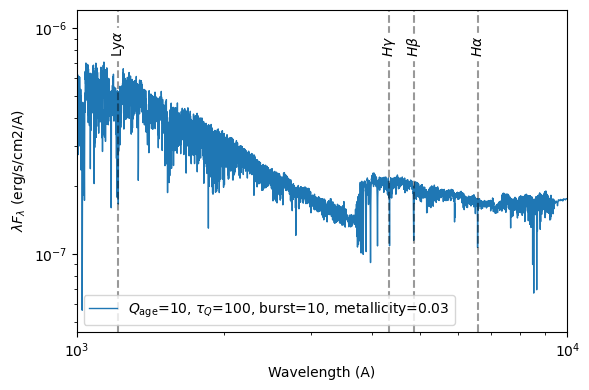

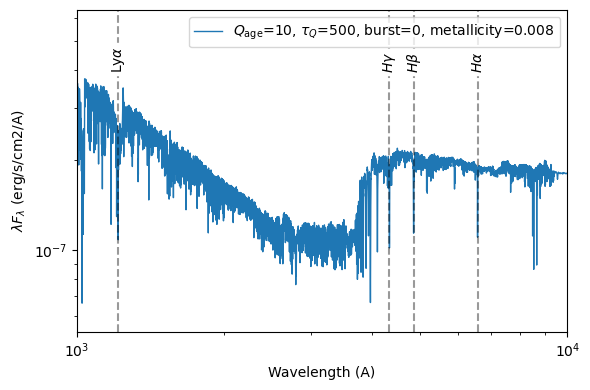

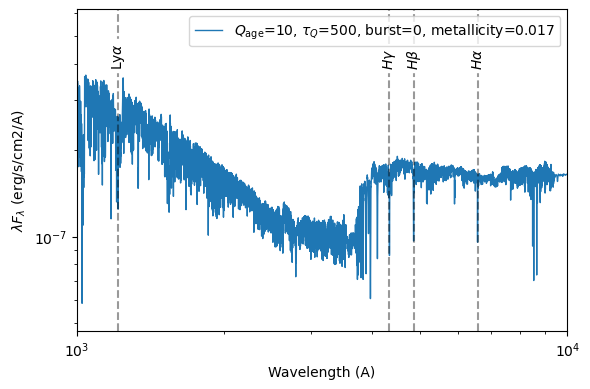

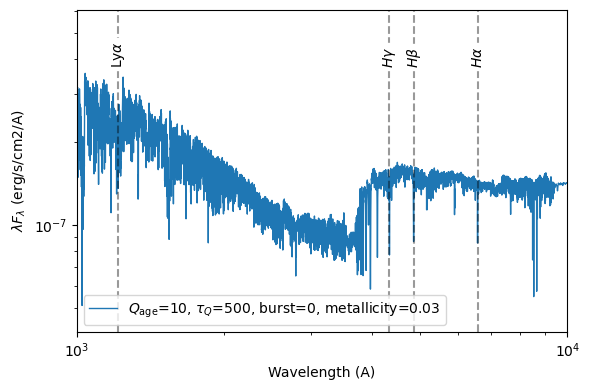

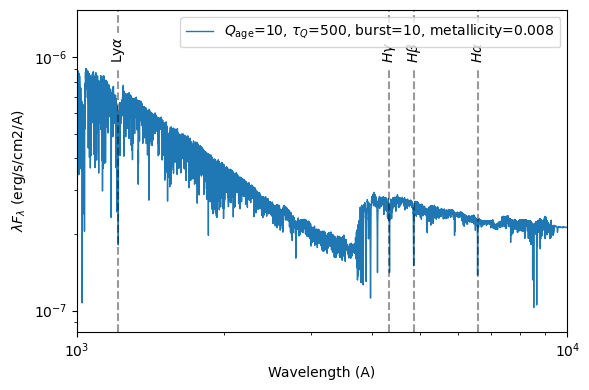

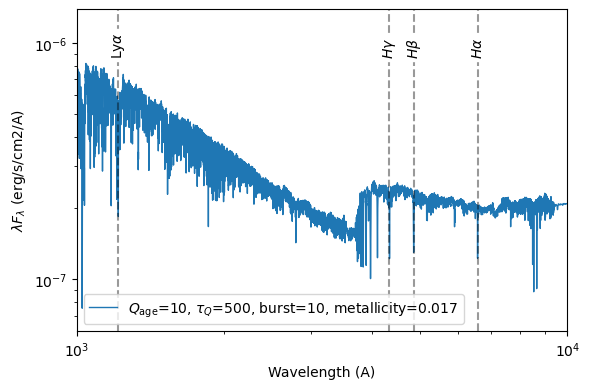

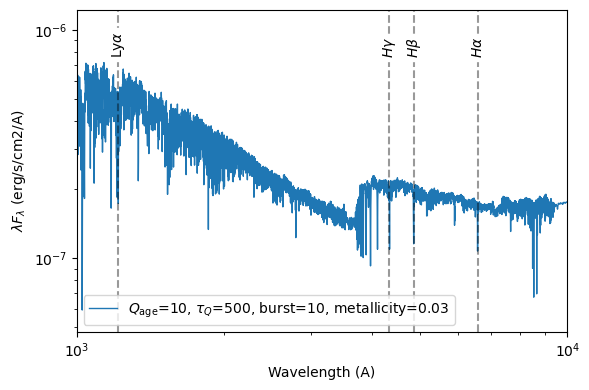

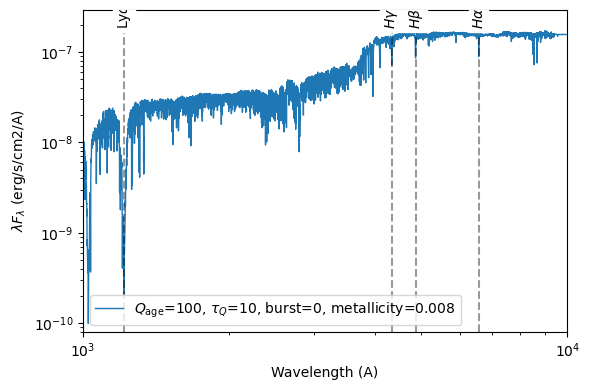

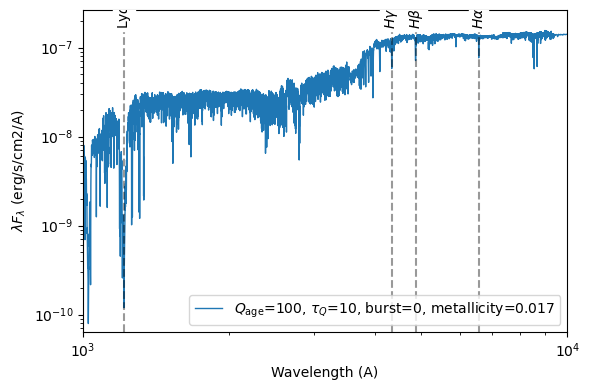

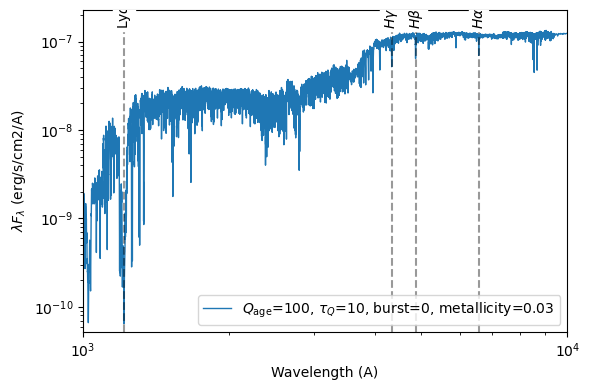

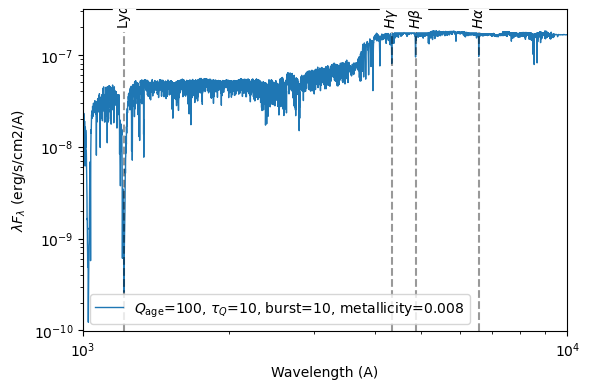

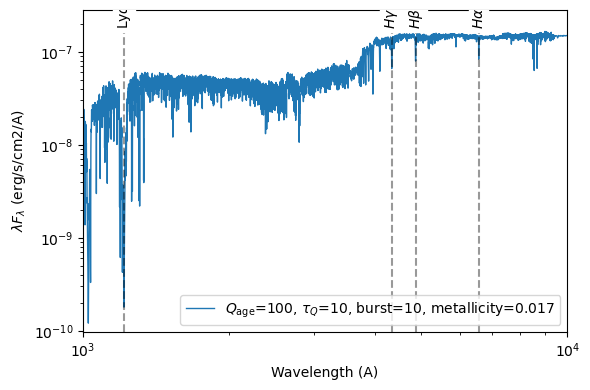

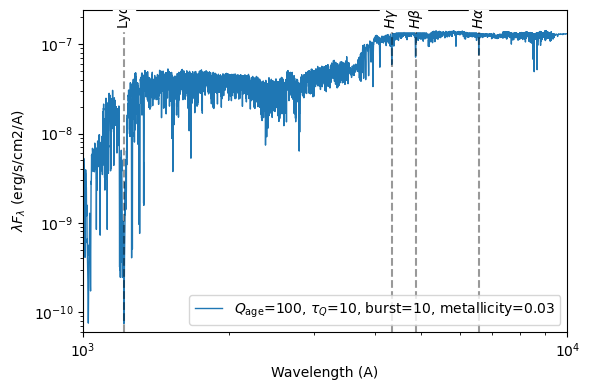

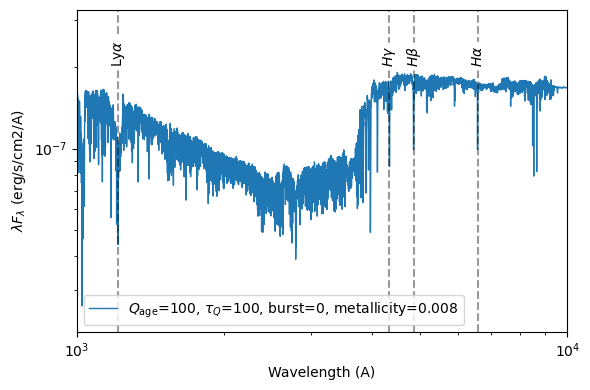

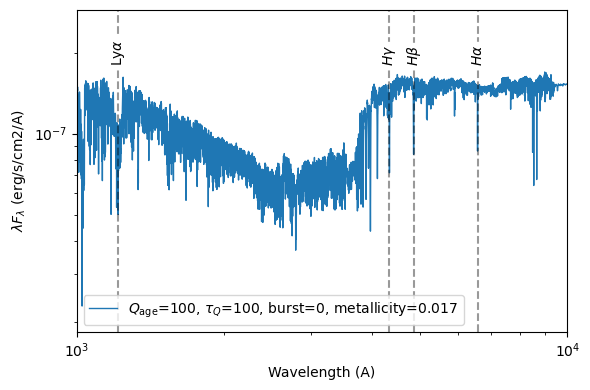

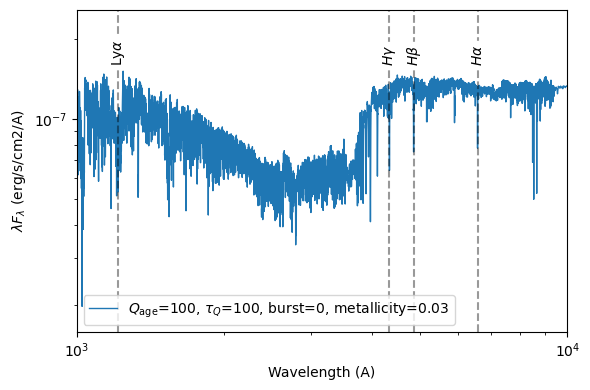

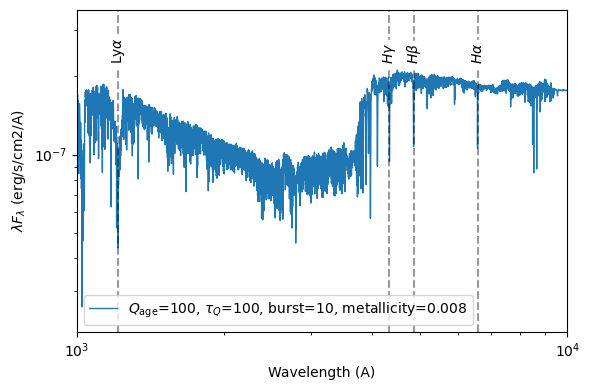

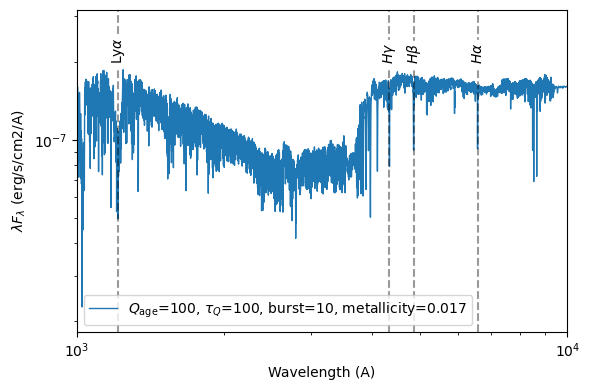

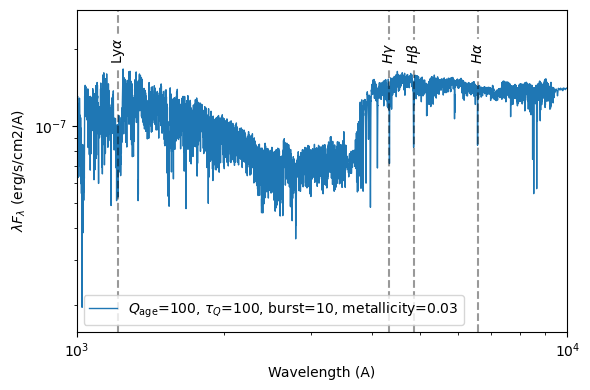

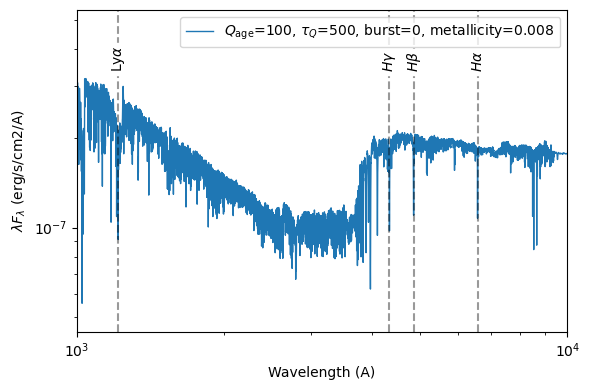

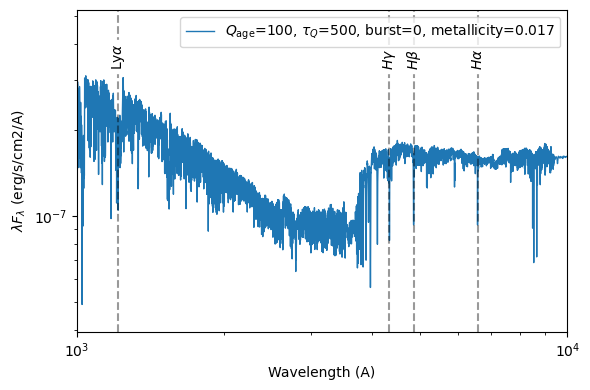

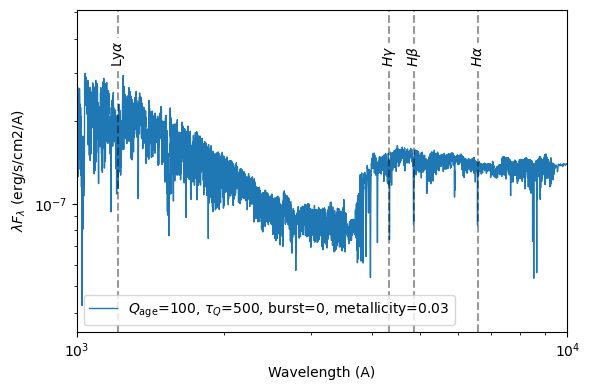

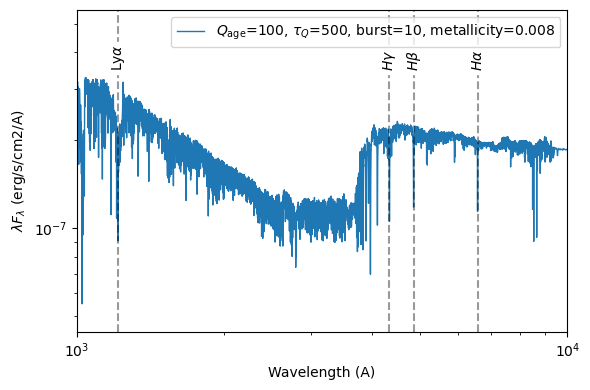

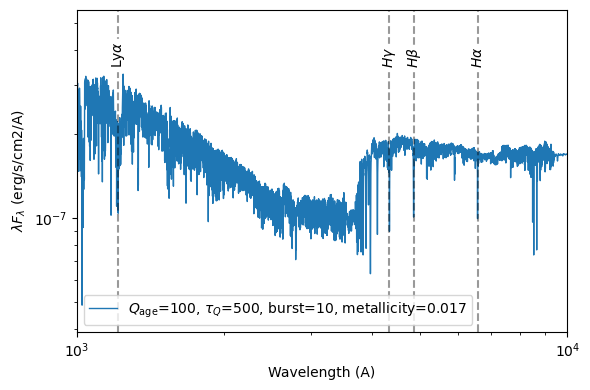

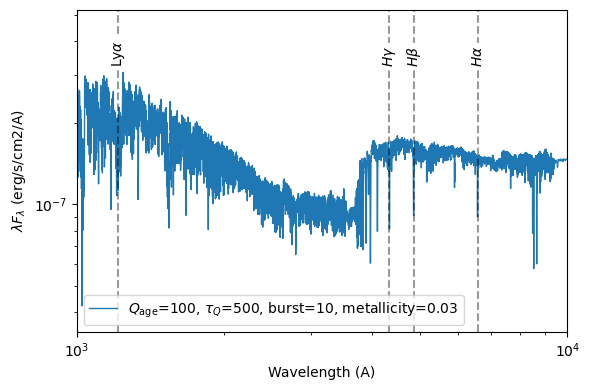

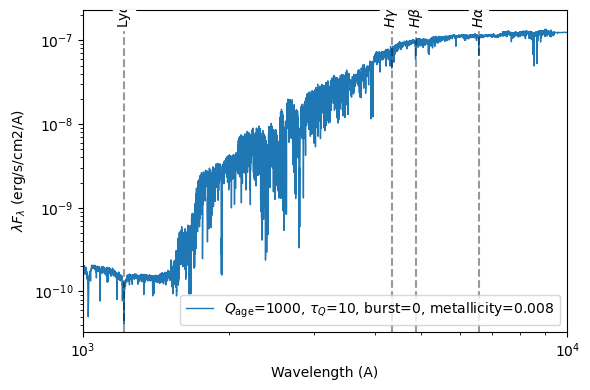

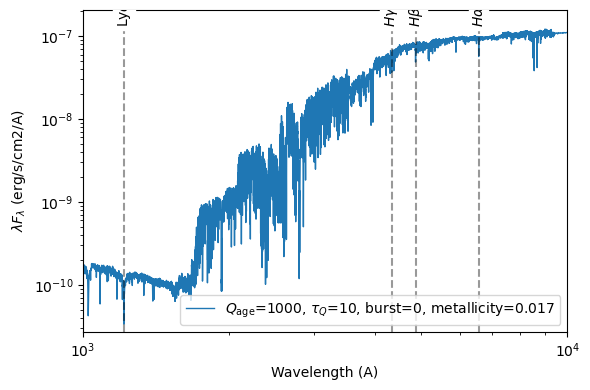

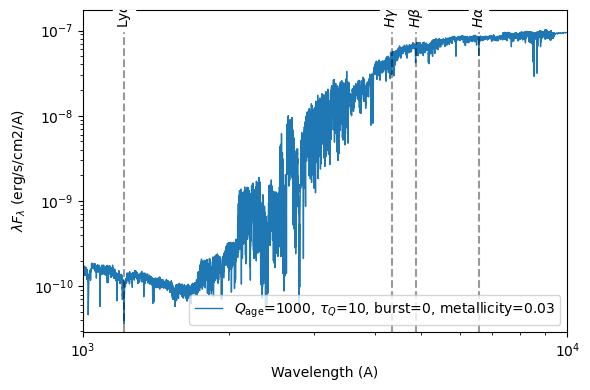

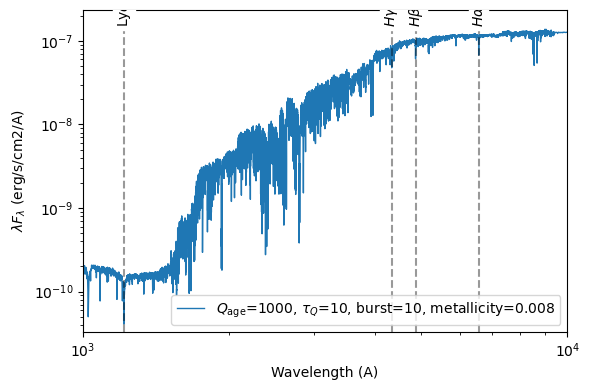

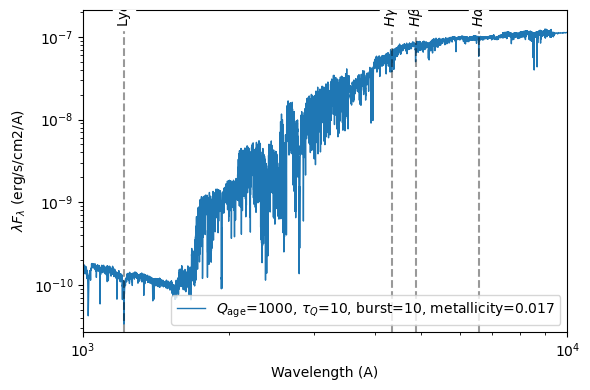

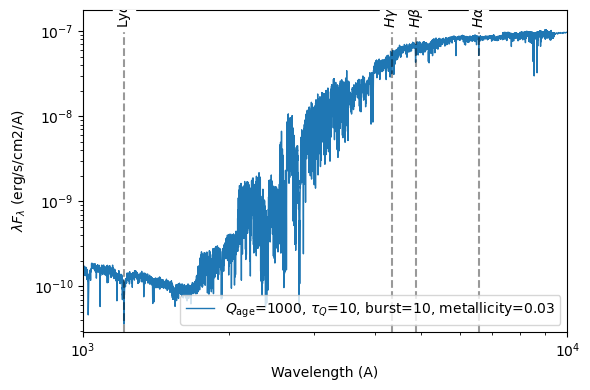

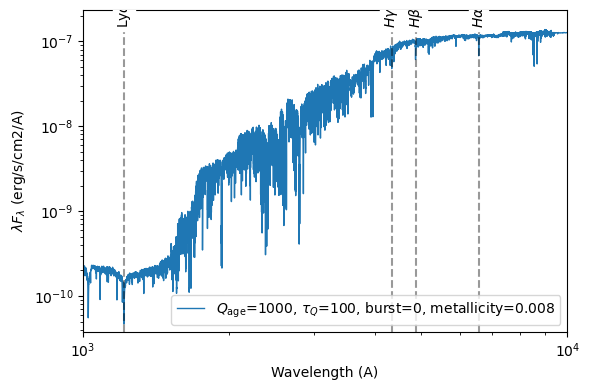

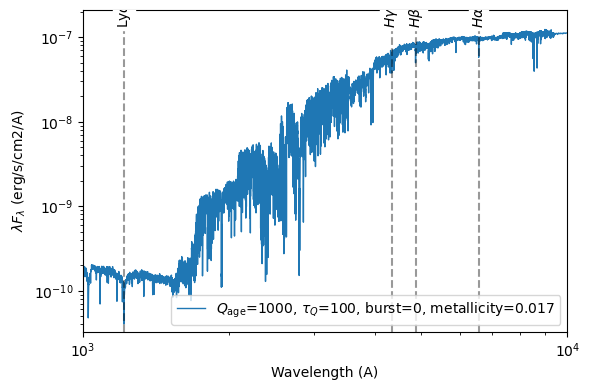

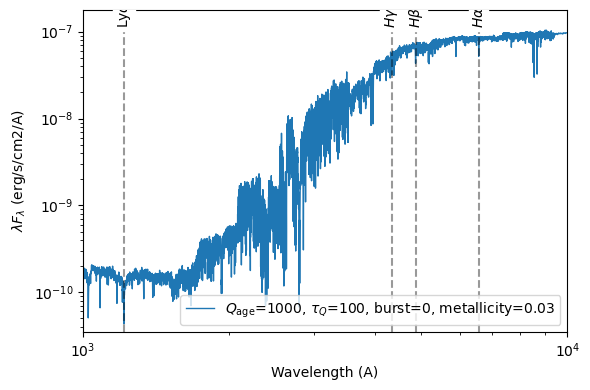

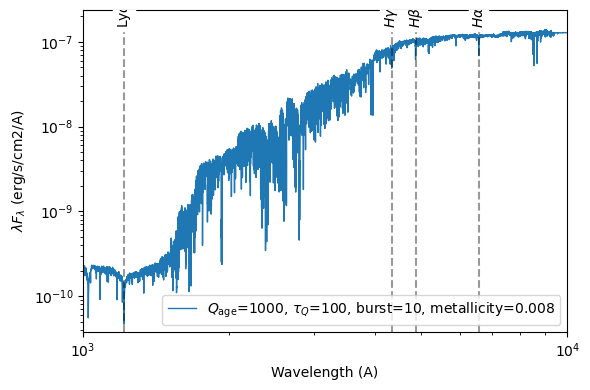

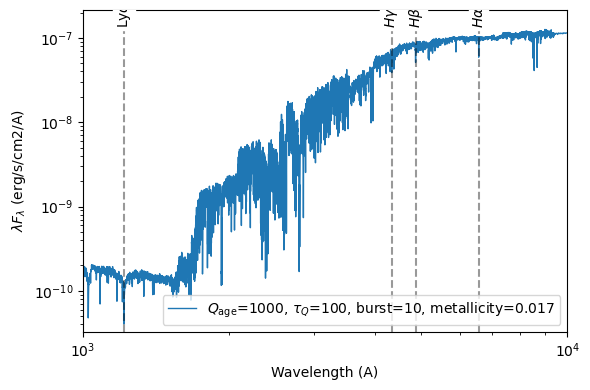

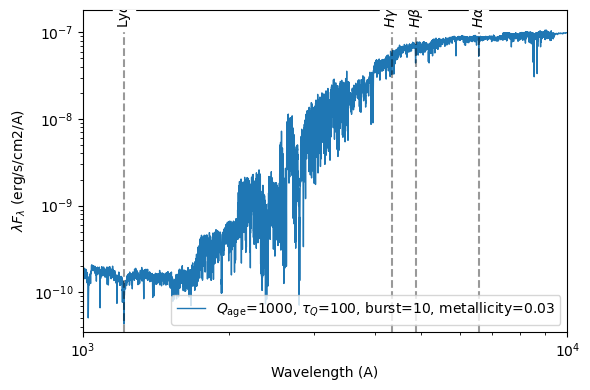

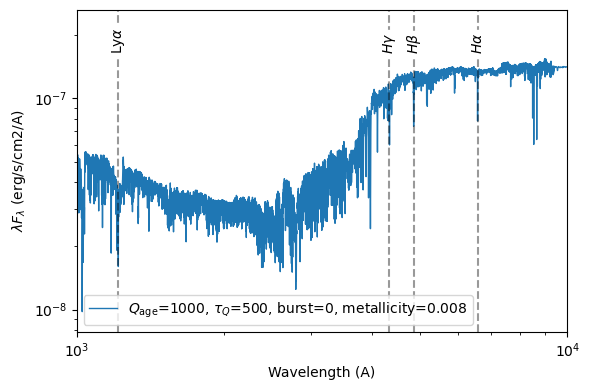

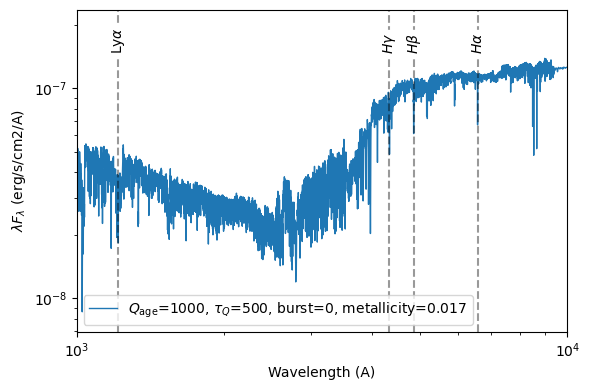

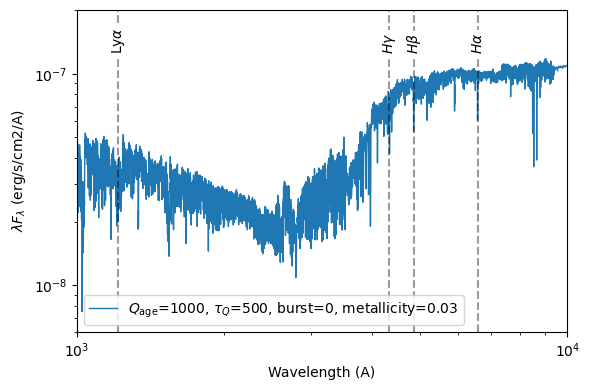

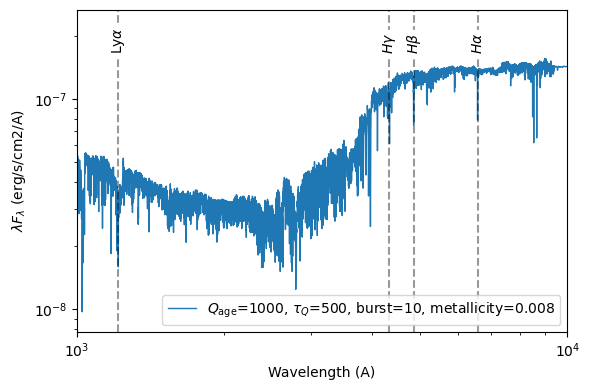

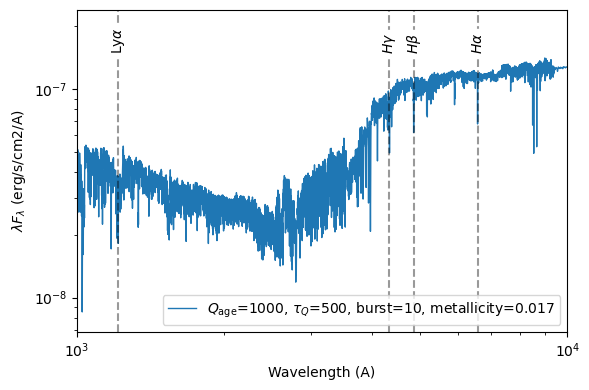

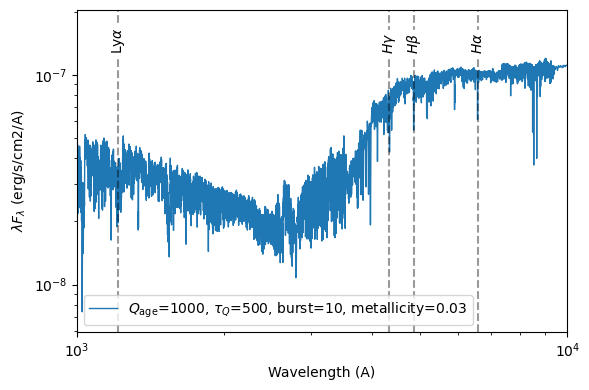

In [25]:
import itertools

for age, tau, burst_factor, metallicity in itertools.product(
        SFH_QUENCHING_AGE, SFH_QUENCHING_TAU, BURST_FACTOR, METALLICITIES):
    
    spec = truncated_boissier_sed(
        V=160, R=5, 
        Q_age=age, tau_Q=tau, 
        burst_factor=burst_factor, 
        metallicity=metallicity, 
        data=boissier_models, AGE=13500
    )

    spec.plot(
        per_wavelength=True,
        show_H_lines=True,
        legend=legend,
        #ymin=7e-8, ymax=1e-6,
        winf=1e3, wsup=1e4,
    )

